In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
#load datasets
customers = pd.read_csv("datasets/olist_customers_dataset.csv")
orders = pd.read_csv("datasets/olist_orders_dataset.csv")
items = pd.read_csv("datasets/olist_order_items_dataset.csv")
products = pd.read_csv("datasets/olist_products_dataset.csv")

In [61]:
orders.head() #check the first few rows of the orders dataset

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [62]:
orders['order_status'].value_counts() #check the distribution of order statuses, we will focus on delivered and canceled orders for return analysis

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [63]:
orders = orders[orders['order_status'].isin(['delivered', 'canceled'])] #cleaning data, only keeping delivered and canceled orders

In [64]:
#merge datasets to create a comprehensive dataframe for analysis
df = orders.merge(customers, on='customer_id') \
           .merge(items, on='order_id') \
           .merge(products, on='product_id')

In [65]:
df.duplicated().sum() #check for duplicates, we should have none after merging

np.int64(0)

In [66]:
df['is_return'] = df['order_status'] == 'canceled' #create a binary column (true/false) to indicate if an order was returned (canceled)
#true when order_status is 'canceled', false when 'delivered'
#dataset is now ready for analysis, we can explore return rates by product category, customer demographics, etc.

In [67]:
df.head() #check the first few rows of the merged dataframe to confirm everything looks correct

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_return
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,False


In [68]:
df['is_return'].value_counts() #check the distribution of returns vs non-returns.

is_return
False    110197
True        542
Name: count, dtype: int64

In [69]:
# RETURN RATE

return_rate = df['is_return'].mean() #true values are treated as 1, false as 0, so mean gives us the percentage of returns
print("Return Rate:", return_rate*100, "%")

Return Rate: 0.4894391316519022 %


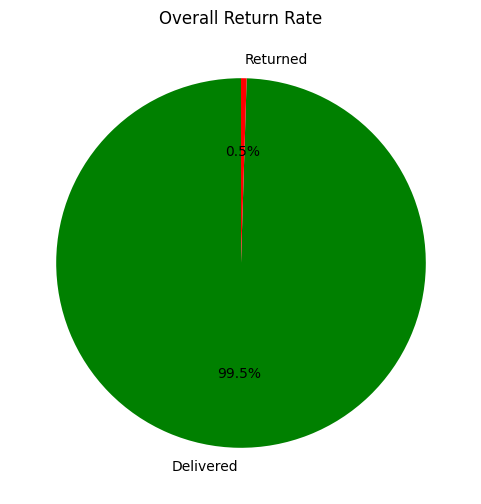

In [70]:
# Return rate counts
return_counts = df['is_return'].value_counts()
labels = ['Delivered', 'Returned']
colors = ['green', 'red']

plt.figure(figsize=(6,6))
plt.pie(return_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Overall Return Rate')
plt.show()

# seaborn does not support pie chart

In [71]:
# PRODUCT RETURN PATTERN

# Filter only returned orders
returns = df[df['is_return']] #Take all rows of df where is_return is True. This gives us a new dataframe called returns that only contains the returned orders.

# Count returns per product, sort by number of returns, highest first
product_returns = returns.groupby('product_id').size().sort_values(ascending=False)

# Top 10 returned products
top_products = product_returns.head(10)
print(top_products)

product_id
5c3eaf54e8ee5d5378765ff16df7640b    6
8397dc503d1a0c2ac7422701884de5a6    6
1c42962612d557f85753b24c2b97070f    5
75f3ef6a5cb0f2d5aeef15925f0ccf69    5
7d4f932dd4fa16256c20de073329eacc    5
66b1f09e746c05761bcaccf6339bde8d    5
3ea32f63a6aaf8d467e543dedf434ee7    5
99b4367cf2228c8a86922a0649bee6b8    5
c3a52053718435a35e070b991ff546ec    5
ed08ea04c92f5f434c2362f7310fb328    5
dtype: int64


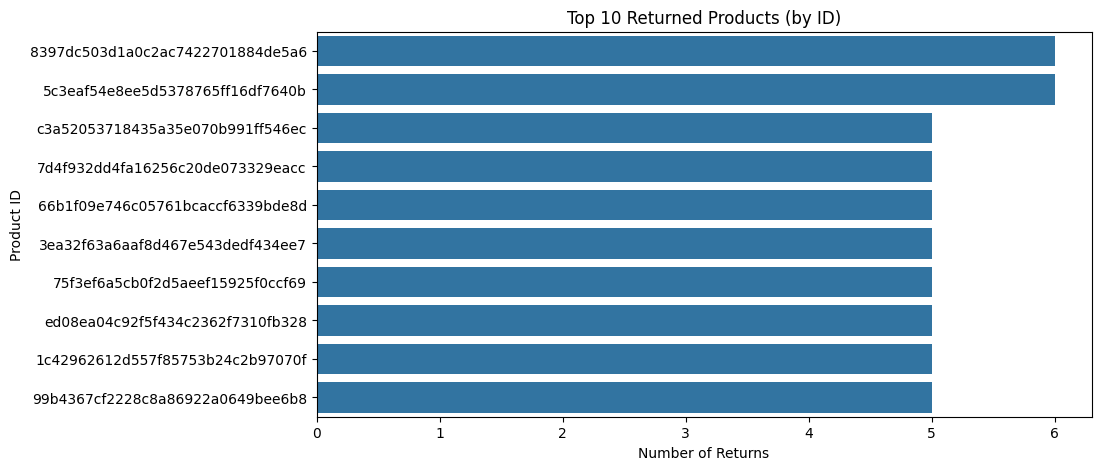

In [72]:
top_products = returns['product_id'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top 10 Returned Products (by ID)")
plt.xlabel("Number of Returns")
plt.ylabel("Product ID")

plt.show()

In [73]:
# CATEGORY RISK

# Group by category: calculate return rate per category
category_risk = df.groupby('product_category_name')['is_return'].mean().sort_values(ascending=False)

# Top 10 risky categories
top_categories = category_risk.head(10)
print(top_categories)

product_category_name
pc_gamer                                         0.111111
portateis_cozinha_e_preparadores_de_alimentos    0.066667
dvds_blu_ray                                     0.031746
construcao_ferramentas_seguranca                 0.026596
fraldas_higiene                                  0.026316
construcao_ferramentas_jardim                    0.016949
instrumentos_musicais                            0.016616
livros_interesse_geral                           0.012868
eletrodomesticos_2                               0.012821
eletroportateis                                  0.012012
Name: is_return, dtype: float64


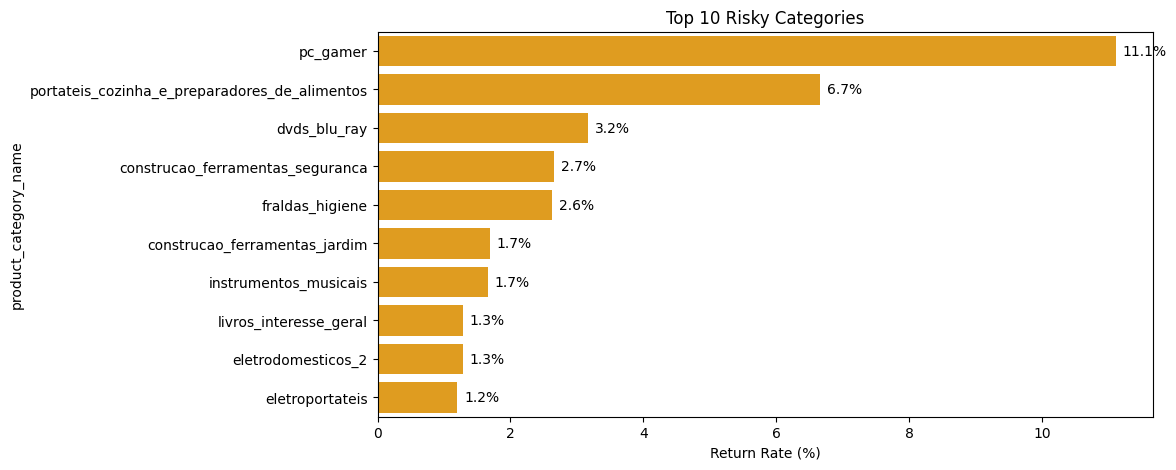

In [ ]:
# Convert to percentage
top_categories_percent = top_categories * 100

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_categories_percent.values,
    y=top_categories_percent.index,
    color='orange'
)

plt.xlabel('Return Rate (%)')
plt.title('Top 10 Risky Categories')

# Add labels
# top_categories_percent.values → all your return rates (numbers)
# enumerate() → gives:
# i = position (0, 1, 2, …) → y-axis position
# v = value (like 12.5, 8.3, etc.)
for i, v in enumerate(top_categories_percent.values):
    plt.text(v + 0.1, i, f'{v:.1f}%', va='center')

plt.show()